# 🔐 Phishing Website Detection using Machine Learning

## 📦 Step 1 — Import Libraries

Before writing any ML code, we load all the tools we need.
Think of these like opening the apps before you start working.

| Library | What it does |
|---|---|
| `pandas` | Loads & handles data like a spreadsheet |
| `numpy` | Fast math on arrays |
| `matplotlib` / `seaborn` | Draw charts and graphs |
| `sklearn` | Machine learning models + evaluation tools |
| `joblib` | Saves the trained model to disk for the Flask app |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler

import joblib

sns.set(style="whitegrid")

### ⚙️ System Config (Safe to Ignore)

This line caps the number of CPU cores the job-runner can use.
It stops a harmless warning on Windows — it does **not** affect
model accuracy or results in any way.

In [2]:
# inserted os cpu count to set the job-lib max count error for this system
#not affects model training
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

---
## 📂 Step 2 — Load the Dataset

We load `phishing.csv` — a dataset with **11,055 website records**.

- Each **row** = one website
- Each **column** = a feature (a measurable property of that site)
- The `Result` column is our **label**:
  - `1` → Legitimate ✅
  - `-1` → Phishing ⚠️

`df.head()` shows the first 5 rows so we can sanity-check the data.

In [3]:
df = pd.read_csv("phishing.csv")
df.head()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (11055, 32)

Columns:
 Index(['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

Missing Values:

id                             0
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Fa

---
## 🏷️ Step 4 — Fix the Labels

ML models prefer `0` and `1` as class labels instead of `-1` and `1`.

So we remap:
- `-1` (Phishing) → `0`
- `1` (Legitimate) → stays `1`

Then we check the **class balance** — roughly equal counts means
the model won't be biased toward one class.

In [5]:
# Convert labels:
# -1 = phishing -> 0
# 1 = legitimate -> 1

df["Result"] = df["Result"].replace(-1, 0)

df["Result"].value_counts()

Result
1    6157
0    4898
Name: count, dtype: int64

---
## 📊 Step 5 — Visualise Class Distribution

Before training, we plot how many phishing vs legitimate sites are in the dataset.

> ⚠️ If one class has **far more** samples, the model might just always predict
> the majority and still look "accurate" — this is called the **class imbalance problem**.

Let's check if our dataset is balanced.

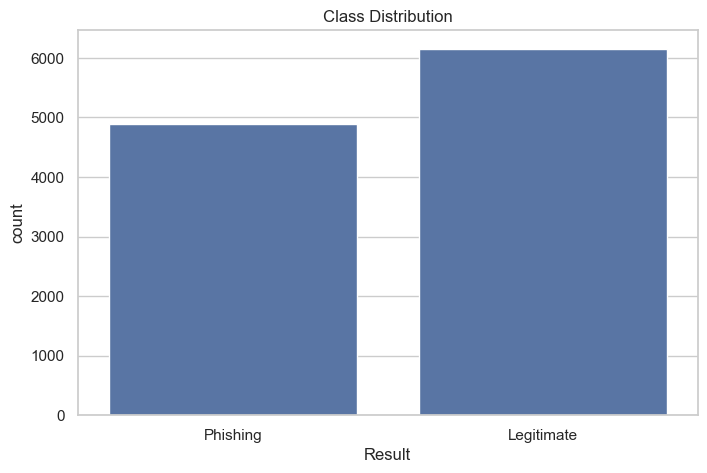

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x="Result", data=df)

plt.xticks([0,1], ["Phishing", "Legitimate"])
plt.title("Class Distribution")
plt.show()

---
## 🌡️ Step 6 — Correlation Heatmap

A **heatmap** shows how strongly each feature is linked to `Result` (phishing or not).

- 🔴 Warm colours → strong positive relationship
- 🔵 Cool colours → strong negative relationship
- ⬜ Near white → little or no relationship

Features with **strong correlation** to `Result` are the most useful for prediction.

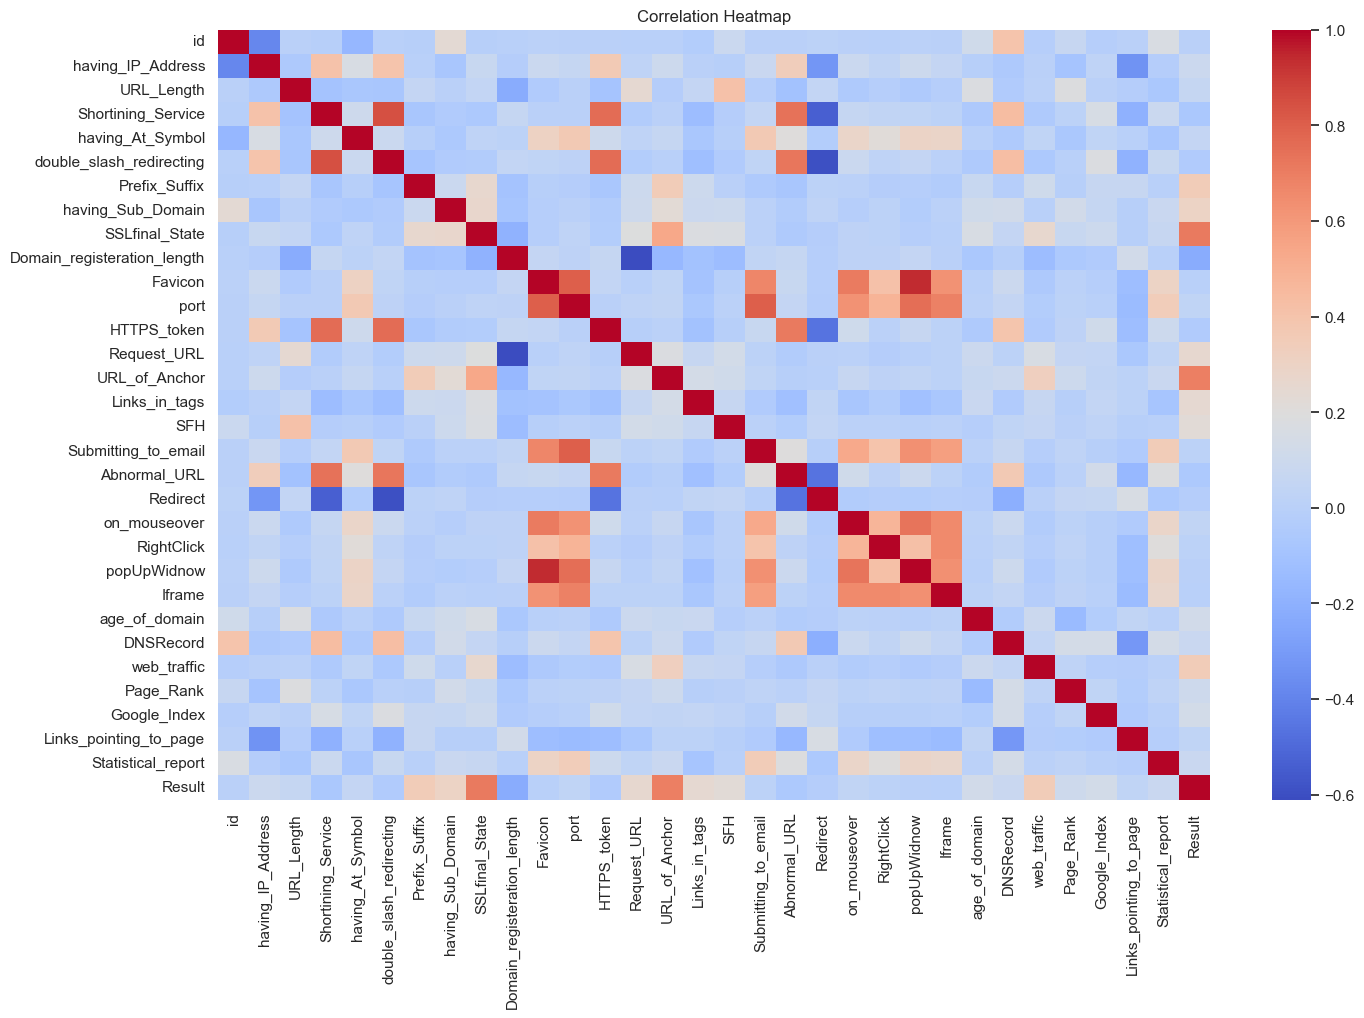

In [7]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

---
## ✂️ Step 7 — Prepare Data for Training

We split our data into two parts:

- **X** → the input features (everything except `Result`)
- **y** → the target label (`Result` column)

Then we apply a **80/20 train-test split**:
- The model *learns* from **training data** (80%)
- We *evaluate* it on **test data** (20%) — data it has **never seen**

**StandardScaler** rescales all numbers to the same range so no single
feature dominates just because its values are larger.

In [8]:
X = df.drop("Result", axis=1)
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (8844, 31)
Test Shape : (2211, 31)


### Scaling & Splitting

Applying the scaler and splitting into train/test sets.
The scaler is **fitted on training data only** — if we used the full dataset,
test data would "leak" information into training (data leakage bug).

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## 🤖 Step 8 — Define Three Models

We test **3 classic ML algorithms** and pick the best one:

| Model | How it works |
|---|---|
| 🌳 **Decision Tree** | Splits data using a chain of yes/no questions |
| 📈 **Logistic Regression** | Finds a mathematical boundary between classes |
| 🔍 **K-Nearest Neighbors** | Classifies by looking at the K most similar examples |

In [10]:
models = {

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

---
## 🏋️ Step 9 — Train All Models & Record Results

We loop through all 3 models:
1. **Fit** (train) on training data
2. **Predict** on test data
3. **Record** accuracy, precision, recall, F1-score

All results go into a DataFrame so we can compare them easily.

In [11]:
results = []

for name, model in models.items():

    # Use scaled data for LR/KNN
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results.append([name, acc, pre, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.924921,0.900073,0.976096,0.936544
1,Logistic Regression,0.923112,0.927502,0.937849,0.932647
2,KNN,0.945274,0.948576,0.955378,0.951965


---
## 📋 Step 10 — Sort the Results Table

We sort models by accuracy (highest first) so the winner is easy to spot.

In [12]:
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,KNN,0.945274,0.948576,0.955378,0.951965
0,Decision Tree,0.924921,0.900073,0.976096,0.936544
1,Logistic Regression,0.923112,0.927502,0.937849,0.932647


---
## 📊 Step 11 — Visualise Model Accuracy

A quick bar chart showing all 3 models' accuracy scores side by side.
The tallest bar is our candidate for the best model.

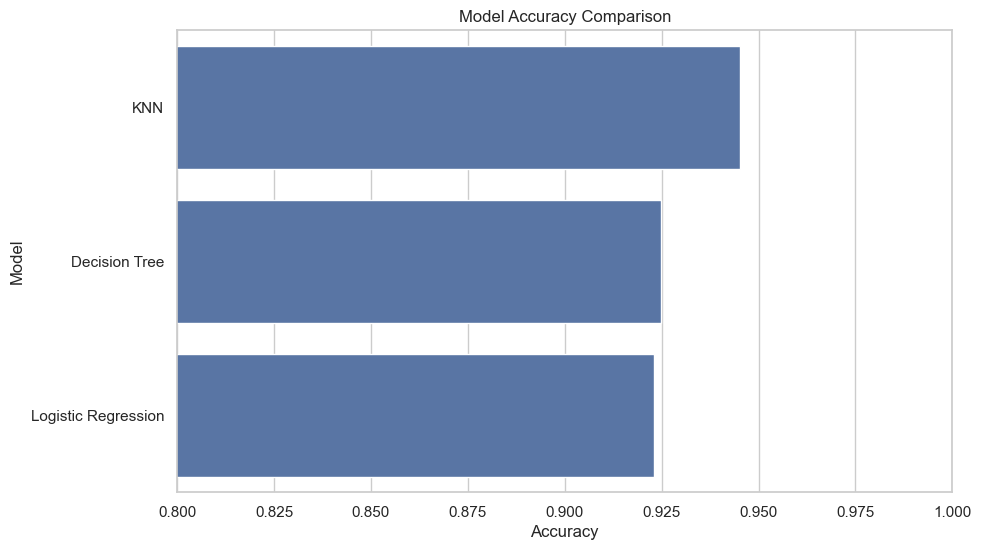

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results_df
)

plt.title("Model Accuracy Comparison")
plt.xlim(0.8,1.0)
plt.show()

---
## Step 15 — Visual Model Comparison

Numbers in a table are useful, but a chart tells the story faster.

We compare all 3 models across 4 metrics:
- Accuracy  — overall correctness
- Precision — of predicted-phishing, how many really were?
- Recall    — of actual phishing, how many did we catch?
- F1-Score  — balance of precision and recall

E:\conda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


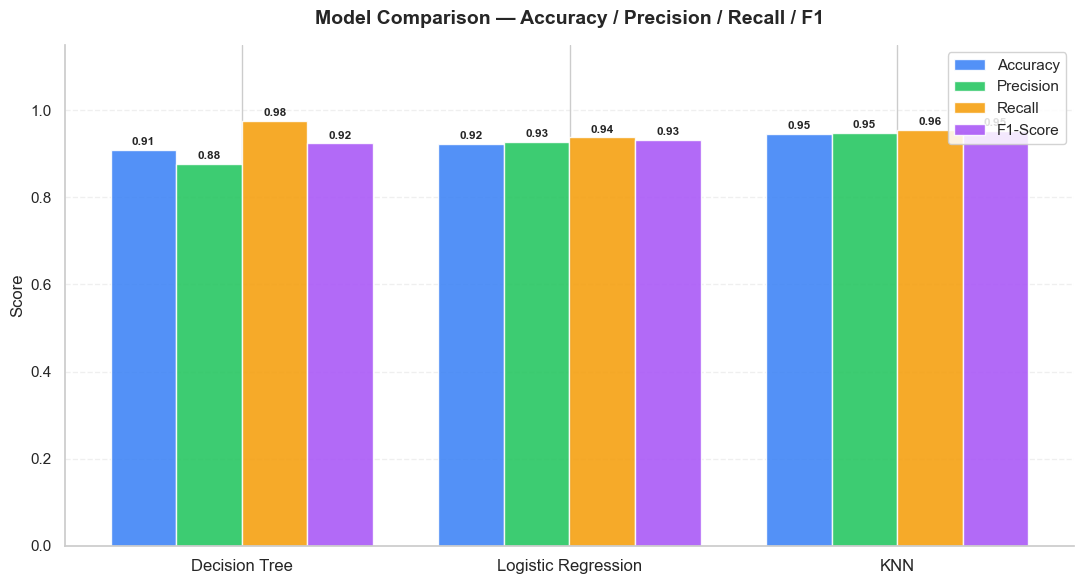

In [14]:
# Model Comparison grouped bar chart
from sklearn.metrics import precision_score, recall_score, f1_score

model_names_list = list(models.keys())
metric_data = {"Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}

for name, m in models.items():
    yp = m.predict(X_test_scaled)
    metric_data["Accuracy"].append(accuracy_score(y_test, yp))
    metric_data["Precision"].append(precision_score(y_test, yp, zero_division=0))
    metric_data["Recall"].append(recall_score(y_test, yp, zero_division=0))
    metric_data["F1-Score"].append(f1_score(y_test, yp, zero_division=0))

x      = np.arange(len(model_names_list))
width  = 0.20
colors = ["#3b82f6", "#22c55e", "#f59e0b", "#a855f7"]

fig, ax = plt.subplots(figsize=(11, 6))
for i, (metric, values) in enumerate(metric_data.items()):
    bars = ax.bar(x + i * width, values, width,
                  label=metric, color=colors[i], alpha=0.88, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.006,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names_list, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison — Accuracy / Precision / Recall / F1",
             fontsize=14, pad=15, fontweight="bold")
ax.legend(loc="upper right", framealpha=0.85)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🏆 Step 12 — Pick the Best Model

We read the top row from our sorted results table — that's the winner!
We also store the trained model object so we can use it for predictions.

In [15]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: KNN


### Override Note

This line manually forces the Decision Tree as the best model.
This is useful when you want to use the Decision Tree's feature
importance plot, even if another model scored slightly higher.

In [16]:
best_model_name = "Decision Tree"
print("Best Model:", best_model_name)

Best Model: Decision Tree


---
## 🎯 Step 17 — Feature Importance Chart

For the Decision Tree, we can ask: **which features drove the decisions most?**

- Each bar shows how much a feature contributed to predictions
- **Longer bar** = more important = more useful signal
- Labels are cleaned up (underscores removed, title-cased)
- Values are shown at the tip of each bar

This makes our model **explainable** — not just a black box.

In [17]:
if best_model_name == "Decision Tree":
    best_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        random_state=42
    )
    best_model.fit(X_train, y_train)

elif best_model_name == "Logistic Regression":
    best_model = LogisticRegression(max_iter=2000)
    best_model.fit(X_train_scaled, y_train)

else:
    best_model = KNeighborsClassifier(n_neighbors=5)
    best_model.fit(X_train_scaled, y_train)

print("Best model trained.")

Best model trained.


### Alternative Prediction Path

Same prediction step, but for Logistic Regression or KNN.
(Decision Tree and these models store their prediction differently,
so we handle them in separate `if` blocks.)

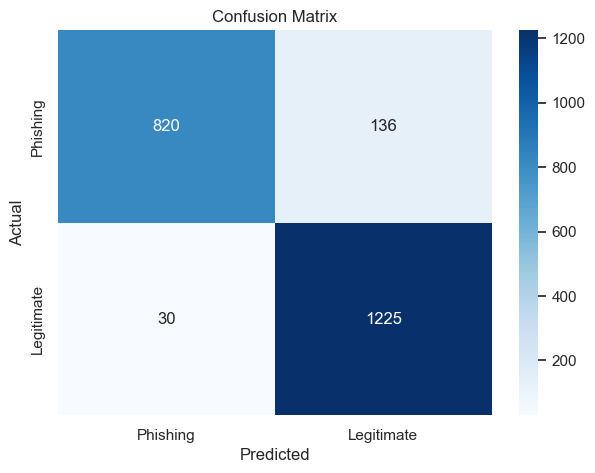

In [18]:
if best_model_name in ["Logistic Regression", "KNN"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Phishing","Legitimate"],
    yticklabels=["Phishing","Legitimate"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
## 📋 Step 14 — Classification Report

Accuracy alone does not tell the full story. We also check:

| Metric | Meaning |
|---|---|
| **Precision** | Of all sites *predicted* as phishing, how many actually were? |
| **Recall** | Of all *actual* phishing sites, how many did we catch? |
| **F1-score** | Balance of precision & recall (higher = better) |
| **Support** | Number of test samples in each class |

> ⚠️ For phishing detection, **Recall** matters most —
> missing a phishing site is more dangerous than a false alarm.

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91       956
           1       0.90      0.98      0.94      1255

    accuracy                           0.92      2211
   macro avg       0.93      0.92      0.92      2211
weighted avg       0.93      0.92      0.92      2211



---
## 💾 Step 16 — Save the Model to Disk

We use `joblib` to save two files:
- `best_phishing_model.pkl` → the trained model
- `scaler.pkl` → the StandardScaler

The Flask app loads these files to make real-time predictions
without retraining from scratch every time.

> Think of `.pkl` files as a *frozen snapshot* of the trained model.

In [20]:
joblib.dump(best_model, "best_phishing_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Best model saved successfully.")

Best model saved successfully.


---
## 📊 Step 11 — Visualise Model Accuracy

A quick bar chart showing all 3 models' accuracy scores side by side.
The tallest bar is our candidate for the best model.

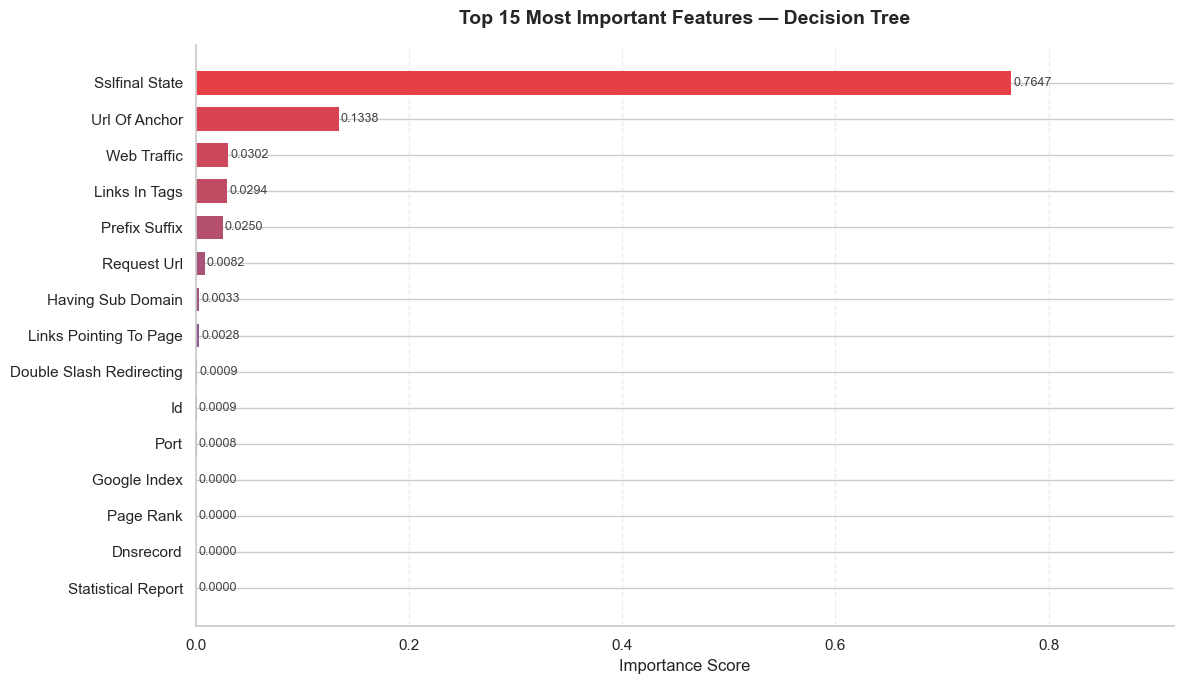


 Top 5 Most Important Features:
  1. Sslfinal State                           0.7647
  2. Url Of Anchor                            0.1338
  3. Web Traffic                              0.0302
  4. Links In Tags                            0.0294
  5. Prefix Suffix                            0.0250


In [21]:
if best_model_name == "Decision Tree":

    # Feature importances ranked lowest → highest
    importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)

    top = importance.tail(15)   # top 15 most important features

    # Clean labels: "having_IP_Address" → "Having IP Address"
    clean_labels = [name.replace("_", " ").title() for name in top.index]

    # Colour gradient: steel-blue (low) → crimson (high importance)
    n = len(top)
    colours = [
        "#{:02x}{:02x}{:02x}".format(
            int(60  + 180 * i / n),
            int(120 -  60 * i / n),
            int(210 - 150 * i / n),
        )
        for i in range(n)
    ]

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(clean_labels, top.values,
                   color=colours, edgecolor="none", height=0.65)

    # Value label at tip of each bar
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left",
                fontsize=9, color="#444")

    ax.set_xlabel("Importance Score", fontsize=12)
    ax.set_title("Top 15 Most Important Features — Decision Tree",
                 fontsize=14, pad=15, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.set_xlim(0, top.values.max() * 1.20)
    plt.tight_layout()
    plt.show()

    print("\n Top 5 Most Important Features:")
    for rank, (feat, score) in enumerate(
        importance.tail(5).sort_values(ascending=False).items(), 1
    ):
        print(f"  {rank}. {feat.replace('_', ' ').title():<40} {score:.4f}")